In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report


data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# =========================================================
# DATASET INFORMATION
# =========================================================

print("Dataset Shape:")
print(X.shape)

print("\nFeature Names:")
print(X.columns.tolist())

print("\nTarget Classes:")
print(data.target_names)

print("\nFirst 5 Rows:")
print(X.head())

print("\nClass Distribution:")
print(y.value_counts())


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Dataset Shape:
(569, 30)

Feature Names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Target Classes:
['malignant' 'benign']

First 5 Rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         2

In [ ]:



n_trees = list(range(1, 301))  # 1 to 300
accuracies = []

for n in n_trees:
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)

    if n % 50 == 0:
        print(f"Trees: {n} | Accuracy: {acc:.4f}")

print("\n==============================")
print("Random Forest Results")
print("==============================")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

# print("Accuracy:", rf_acc)

# print("\nClassification Report:")
# print(classification_report(y_test, rf_pred))



Trees: 50 | Accuracy: 0.9561
Trees: 100 | Accuracy: 0.9561
Trees: 150 | Accuracy: 0.9561
Trees: 200 | Accuracy: 0.9561
Trees: 250 | Accuracy: 0.9474
Trees: 300 | Accuracy: 0.9474

Random Forest Results


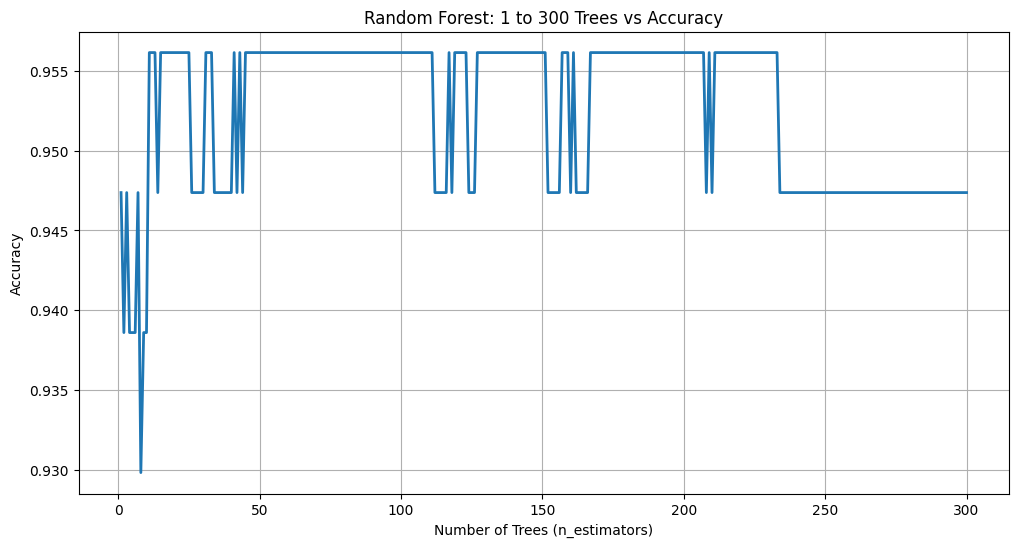

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(n_trees, accuracies, linewidth=2)

plt.title("Random Forest: 1 to 300 Trees vs Accuracy")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")

plt.grid(True)
plt.show()


Top Important Features:
                 Feature  Importance
23            worst area    0.140016
27  worst concave points    0.129530
20          worst radius    0.097696
7    mean concave points    0.090885
22       worst perimeter    0.072226
2         mean perimeter    0.069574
0            mean radius    0.068676
6         mean concavity    0.057638
3              mean area    0.049172
26       worst concavity    0.034340


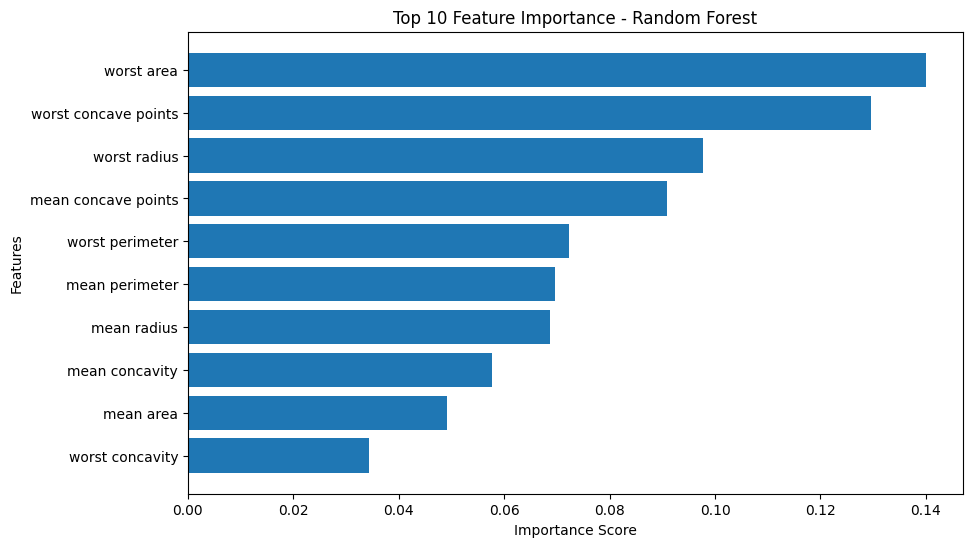

In [ ]:

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Important Features:")
print(feature_importance.head(10))


plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance - Random Forest")

plt.show()


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(
    kernel='rbf',
    C=1.0
)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, svm_pred)

print("\n==============================")
print("SVM Results")
print("==============================")

print("Accuracy:", svm_acc)

print("\nClassification Report:")
print(classification_report(y_test, svm_pred))


SVM Results
Accuracy: 0.9824561403508771

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

